In [1]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import umap

/home/ykuenzi/miniforge3/envs/iml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SNE/t-SNE explanation

## Stochastic Neighbor Embedding (SNE)

SNE tries to find a low dimensional (i.e., 2/3D) projection of a high dimensional dataset that preserves similarity.
That is, points that are close in the high dimensional space should also be close in the projection, whereas far away points do not necessarily have to be far away in the projection. Is is done by modelling similarities as conditional probabilities, so the similarity of points $x_i$ and $x_j$ in the high-dimensional space is given by
$$
    p_{j\mid i} = \frac{\exp(-\lVert x_i - x_j\rVert^2/2\sigma_i^2)}{\sum_{k\neq i}\exp(-\lVert x_i - x_k\rVert^2/2\sigma_i^2)}.
$$
So we use a Gaussian kernel centered at $x_i$ to randomly pick a neighbor, close points (w.r.t euclidian distance) are more likely to be picked and the probability of $x_j$ being picked as the neighbor of $x_i$ is used as the similarity score between $x_i$ and $x_j$.

Similarly, the similarity in the low dimensional space is also defined as a conditional probability using a Gaussian kernel, here we uses a fixed variance $\sigma^2$ for all $y_i$. That is, the similarity between $y_i$ and $y_j$ is given by
$$
    q_{j\mid i} = \frac{\exp(-\lVert y_i - y_j\rVert^2)}{\sum_{k\neq i}\exp(-\lVert y_i - y_k\rVert^2)}.
$$
We now have $2n$ distributions $P_i, Q_i$ and want to make them as similar as possible to preserve the similarity measures between the points. To achieve this, we can use gradient descent on the cost function
$$
    C = \sum_{i}\mathrm{KL}(P_i\Vert Q_i) = \sum_i\sum_j p_{j\mid i}\log{\frac{p_{j\mid i}}{q_{j\mid i}}}.
$$
Due to the asymmetry of the KL divergence, positioning similar points far away is penalized more severly than positioning dissimilar points close together.

## t-Distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE is an adaption of vanilla SNE. The problem with SNE is that the cost function $C$ is difficult to optimize and can lead to crowding. To alleviate these issues, t-SNE uses a symmetric similarity measure and a the $t$-distribution to model similarities in the low dimensional space. The heavier tails of the $t$-distribution counteract the crowding problem as they allow moderate distances in the high dimensional space to be modelled accurately by a somewhat large distance in the low dimensional space.

# Implementation

In [8]:
# Load data normalized, standardized and preprocessed by Patrick
df = pd.read_csv("train_data_yeo.csv")
[col for col in df.columns if "%" in col or "percentage" in col]

['field goals, %',
 '3-pt field goals, %',
 'free throws, %',
 '2-pt field goals, %',
 'true shooting percentage',
 'effective field goal percentage']

In [9]:
categories = {
    "Boxscore": ["points", "points per player's possession", "field goals made",
       "field goals attempted", "3-pt field goals made",
       "3-pt field goals attempted", "free throws made",
       "free throws attempted", "rebounds",
       "offensive rebounds", "defensive rebounds", "assists", "steals",
       "turnovers", "blocks", "fouls", "fouls drawn", 
       "2-pt field goals made", "2-pt field goals attempted",
       "points off assists", "screen assist",
       "points off screen assists"],
    "Efficiency": ["number of player's possessions",
       "team points with player", "offensive rating",
       "opponent possessions played", "opponent's points with player",
       "defensive rating", "plus/minus", "net rating", "assists to turnovers",
       "steals to turnovers", "draw foul rate", "true shooting percentage",
       "effective field goal percentage"],
}


In [12]:
# Project into 2d using t-SNE
proj = TSNE().fit_transform(df[categories["Efficiency"]])
#proj = umap.UMAP().fit_transform(df[categories["Efficiency"]])

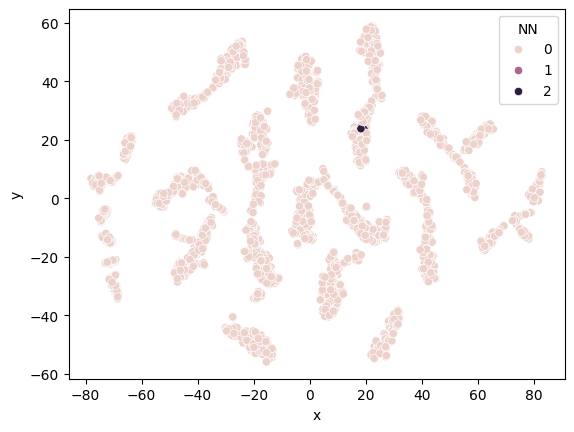

In [35]:
# Convert to pandas df and add nearest neighbor column to show NN in scatterplot
sub = proj#[:400]
proj_df = pd.DataFrame(sub).rename({0: "x", 1: "y"}, axis="columns")
proj_df.insert(len(proj_df.columns), "NN", 0)
highlight = 800
proj_df.at[highlight, "NN"] = 1
#others = np.concatenate((sub[:highlight], sub[highlight+1:]))
#dist = np.linalg.norm((others - sub[highlight]), axis=1)
others = np.concatenate((np.array(proj_df)[:highlight], np.array(proj_df)[highlight+1:]))
dist = np.linalg.norm((others - np.array(proj_df)[highlight]), axis=1)
idx = np.argpartition(dist, 5)[:5]
idx = np.array([i + 1 if i >= highlight else i for i in idx])
for i in idx:
    proj_df.at[i, "NN"] = 2
plot = sns.scatterplot(data=proj_df, x="x", y="y", hue="NN")
plot.get_figure().savefig("boxscore-umap.png")